[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 10 Linear Regression
- Detection and Attribution

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from scipy import stats
import matplotlib.pyplot as plt

### Global Mean Temperature from GCMs

- Data

In [3]:
d = pd.read_csv("synthetic_DA_data.csv")
ctrl = pd.read_csv("synthetic_DA_control.csv")["control"]
d["fGHG"] = d["fALL"] - d["fAER"] - d["fNAT"]

o = d["obs_proxy"] #observed proxy
X = sm.add_constant(d[["fGHG", "fAER", "fNAT"]])
d

,year,obs_proxy,fALL,fAER,fNAT,fGHG_true,fAER_true,fNAT_true,fGHG
0,1950,0.024621,0.009810,-0.043181,0.008882,0.000000,-0.030343,2.969464e-02,0.044110
1,1951,0.042594,0.019178,-0.028042,0.013087,0.006666,-0.034040,2.267249e-02,0.034133
2,1952,0.005260,0.017673,-0.011017,0.016567,0.013510,-0.038140,8.451977e-03,0.012123
3,1953,-0.012043,-0.032468,-0.028535,-0.004718,0.020537,-0.042676,-8.451977e-03,0.000785
4,1954,-0.012613,-0.047704,-0.041353,-0.023662,0.027751,-0.047681,-2.267249e-02,0.017311
...,...,...,...,...,...,...,...,...,...
63,2013,0.684286,0.714796,-0.356515,0.001774,1.062063,-0.352156,-1.496340e-07,1.069537
64,2014,0.791150,0.763629,-0.373104,0.002892,1.097049,-0.350372,1.621915e-02,1.133841
65,2015,0.762196,0.814072,-0.379850,-0.007401,1.132968,-0.348563,2.728892e-02,1.201323
66,2016,0.627741,0.830610,-0.374008,0.024934,1.169845,-0.346731,2.969462e-02,1.179685


- OLS fit

In [5]:
# 2. OLS fit
res = sm.OLS(o, X).fit()
print(res.params.round(3))
#you can also do res.summary()

const   -0.030
fGHG     0.877
fAER     0.726
fNAT     0.581
dtype: float64


In [7]:
# 3. Effective sample size
#Considering autocorrelation
n, p = len(o), len(res.params)
r1 = acf(ctrl, nlags=1)[1] #autocorrelation 1
n_eff = n * (1 - r1) / (1 + r1)
t = stats.t.ppf(0.975, n_eff - p) #use neff to get tcrit
print(r1)

0.407077554977729


In [8]:
# 4. CI = β ± t × SE
#look at SE for each parameter
beta = res.params.drop("const")
se = res.bse.drop("const") * np.sqrt(n / n_eff)
CI_high = beta + t * se
CI_low = beta - t * se

In [9]:
print('CI_high:\n',CI_high)
print('CI_low:\n',CI_low)

CI_high:
 fGHG    1.094786
fAER    1.340541
fNAT    1.289729
dtype: float64
CI_low:
 fGHG    0.660198
fAER    0.110933
fNAT   -0.128004
dtype: float64


## HW -- hands-on --

In [10]:
## 1. Data
d = pd.read_csv("NH_PI_DA_input.csv")
reg = d.dropna(subset=["year"]).copy()        # 1850-2005 (156 years)
control = d["NH_control"].dropna()            # 500-year control run

# Natural response: hist_aer = GHG + NAT  ->  NAT = hist_aer - GHG
reg["GHG"] = reg["NH_GHG"]
reg["AER"] = reg["NH_aerosols"]
reg["NAT"] = reg["NH_hist_aer"] - reg["NH_GHG"] #get natural from hist aer and ghg
obs = reg["NH_obs_proxy"]
reg

,year,NH_obs_proxy,NH_GHG,NH_aerosols,NH_hist_aer,NH_control,GHG,AER,NAT
0,1850.0,-0.3579,-1.1447,1.3348,-1.0064,0.2934,-1.1447,1.3348,0.1383
1,1851.0,-0.1012,-1.0953,1.2948,-0.9675,0.3427,-1.0953,1.2948,0.1278
2,1852.0,0.1311,-1.1265,1.4013,-1.0611,0.2626,-1.1265,1.4013,0.0654
3,1853.0,-0.0063,-1.1401,1.2309,-1.1331,0.2031,-1.1401,1.2309,0.0070
4,1854.0,0.1907,-1.1774,1.2162,-1.2177,0.7088,-1.1774,1.2162,-0.0403
...,...,...,...,...,...,...,...,...,...
151,2001.0,-0.0793,0.2444,-0.1167,0.3485,-0.1346,0.2444,-0.1167,0.1041
152,2002.0,-0.1745,0.2282,-0.1588,0.4495,-0.2829,0.2282,-0.1588,0.2213
153,2003.0,0.0187,0.3191,-0.3008,0.4545,-0.2824,0.3191,-0.3008,0.1354
154,2004.0,0.1140,0.3622,-0.3270,0.5001,0.0381,0.3622,-0.3270,0.1379


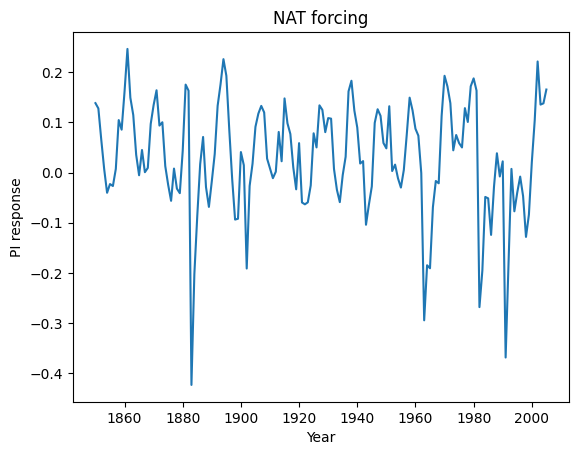

In [11]:
## plot Nat forcing
plt.plot(reg["year"],reg["NAT"])
plt.title('NAT forcing')
plt.xlabel('Year')
plt.ylabel('PI response')
plt.savefig('PI_NA.png')

In [ ]:
# 2. fit the OLS
res = sm.OLS(o, X).fit()
print(res.params.round(3))

In [ ]:
# 3. Effective sample size from the control run


In [ ]:
# 4. Corrected standard errors and t critical value


In [ ]:
# 5. CI low and high


In [ ]:
# 6. attributable cahnge (fit data with year)
## for 1850-2005
period = reg[(reg["year"] >= 1850) & (reg["year"] <= 2005)]


In [ ]:
## for 1950-2005
period = reg[(reg["year"] >= 1950) & (reg["year"] <= 2005)]
